## #Build a model to find whether the person is defaulter or not when income and balance of the person is provided

In [38]:
import pandas as pd

In [39]:
data = pd.read_csv("Default.csv")

In [40]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [42]:
data["default"].unique()

array(['No', 'Yes'], dtype=object)

In [43]:
data["student"].unique()

array(['No', 'Yes'], dtype=object)

<function matplotlib.pyplot.show(close=None, block=None)>

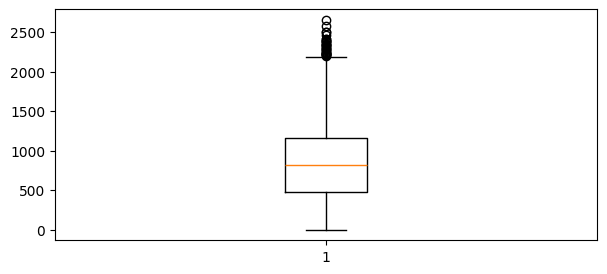

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,3))
plt.boxplot(data["balance"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

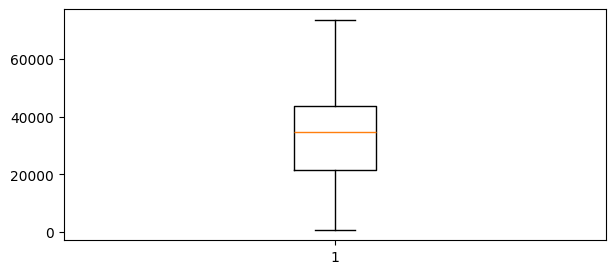

In [45]:
plt.figure(figsize=(7,3))
plt.boxplot(data["income"])
plt.show

In [46]:
Q1 = data["balance"].quantile(0.25)
Q3 = data["balance"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(-545.1348175), np.float64(2193.1743093))

In [47]:
data[data["balance"]>upper_limit].count()

default    31
student    31
balance    31
income     31
dtype: int64

In [48]:
data.describe()      # give the statistical data

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


In [49]:
data = data.drop(data[data["balance"]>upper_limit].index)

In [50]:
data.shape

(9969, 4)

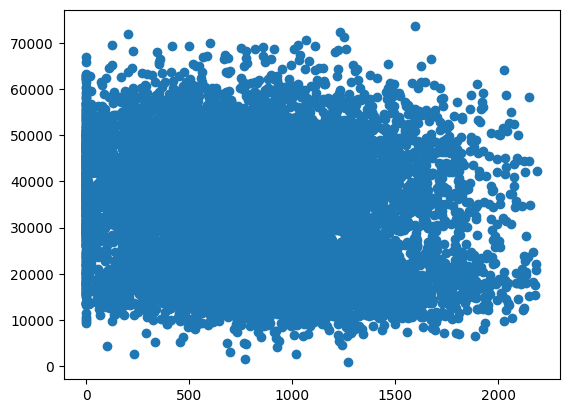

In [51]:
plt.scatter(data["balance"],data["income"])

In [52]:
import seaborn as sns

In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["student"] = le.fit_transform(data["student"])
data["default"] = le.fit_transform(data["default"])


<Axes: >

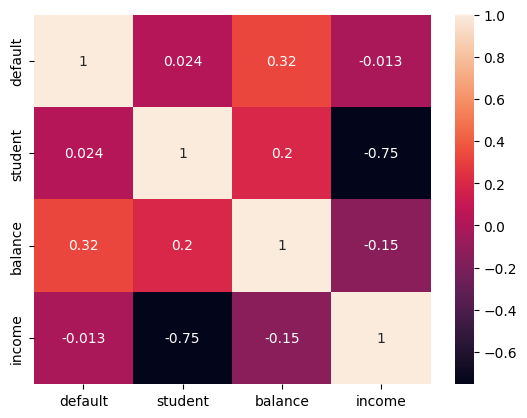

In [54]:
sns.heatmap(data.corr(),annot=True)

In [55]:
x = data.drop("default",axis = 1).values
y = data["default"].values


In [56]:
x.shape

(9969, 3)

In [57]:
x = data.drop('default', axis=1)
y = data['default']

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [60]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [61]:
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [62]:
test_pred = knn.predict(x_test)

In [63]:
test_pred.size

2991

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
accuracy_score(y_test, test_pred)

0.9715814108993648

In [66]:
y_test.value_counts()

default
0    2913
1      78
Name: count, dtype: int64

In [67]:
from sklearn.metrics import confusion_matrix

In [68]:
confusion_matrix(y_test, test_pred)

array([[2895,   18],
       [  67,   11]])

In [69]:
test_acc = []
train_acc = []
k = []

for i in range(3, 16, 2):
    k.append(i)
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    train_pred = knn.predict(x_train)
    test_pred = knn.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_pred))
    train_acc.append(accuracy_score(y_train, train_pred))

In [70]:
print(train_acc)

[0.9770707939237604, 0.972341645170536, 0.970908569790771, 0.9697621094869591, 0.9693321868730295, 0.9683290341071941, 0.967755803955288]


In [71]:
print(test_acc)

[0.9672350384486794, 0.9715814108993648, 0.9739217652958877, 0.9749247743229689, 0.974256101638248, 0.9735874289535272, 0.9735874289535272]


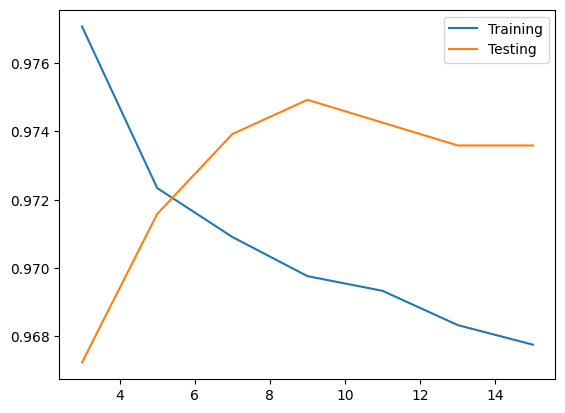

In [72]:
plt
plt.plot(k, train_acc)
plt.plot(k, test_acc)
plt.legend(["Training", "Testing"])
plt.show()

In [73]:
from sklearn.model_selection import cross_validate

In [75]:
knn = KNeighborsClassifier()
val_result = cross_validate(knn, x_train, y_train)
val_result

{'fit_time': array([0.00499558, 0.00500107, 0.00600338, 0.01000929, 0.0109911 ]),
 'score_time': array([0.00700498, 0.00599623, 0.00599766, 0.08200288, 0.02701235]),
 'test_score': array([0.96919771, 0.96346705, 0.96776504, 0.9655914 , 0.9655914 ])}

In [77]:
train_acc = val_result['test_score'].mean()
print("Training acc:", train_acc)

Training acc: 0.9663225190251719
